In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

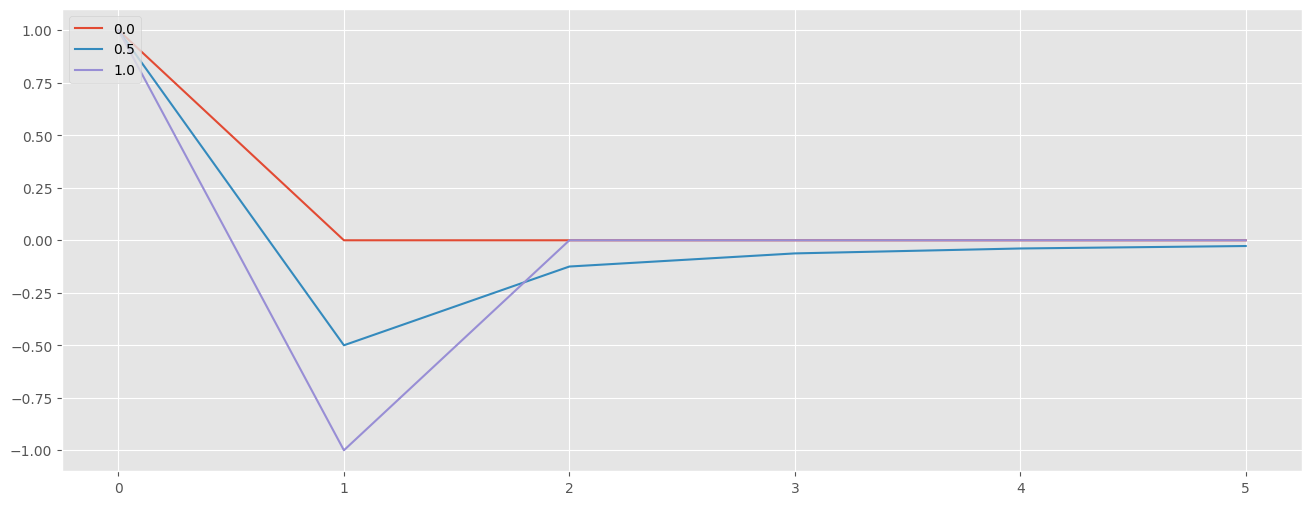

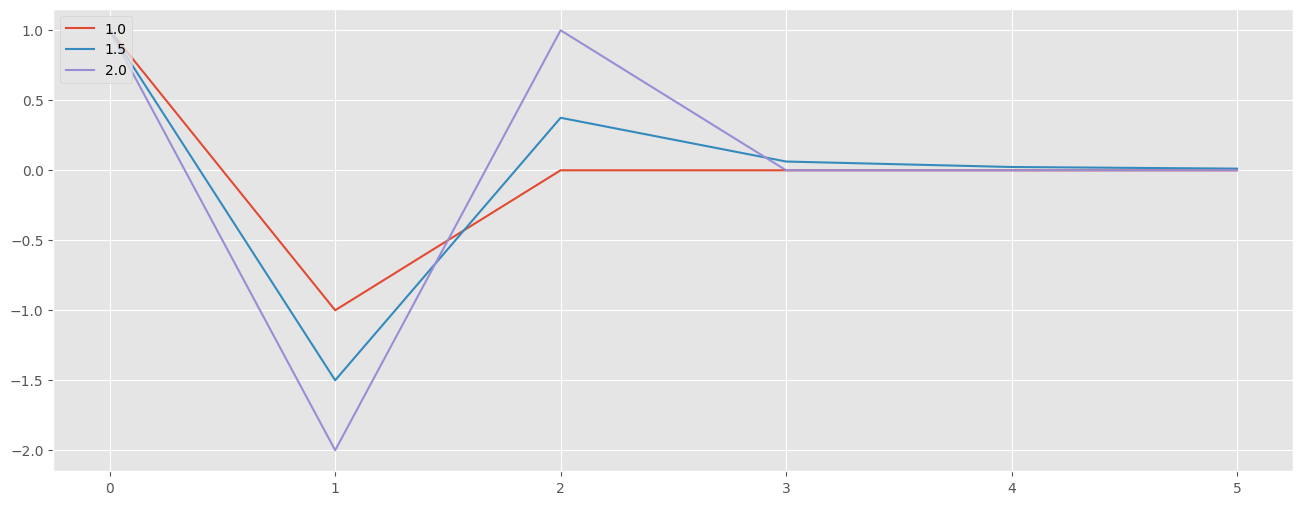

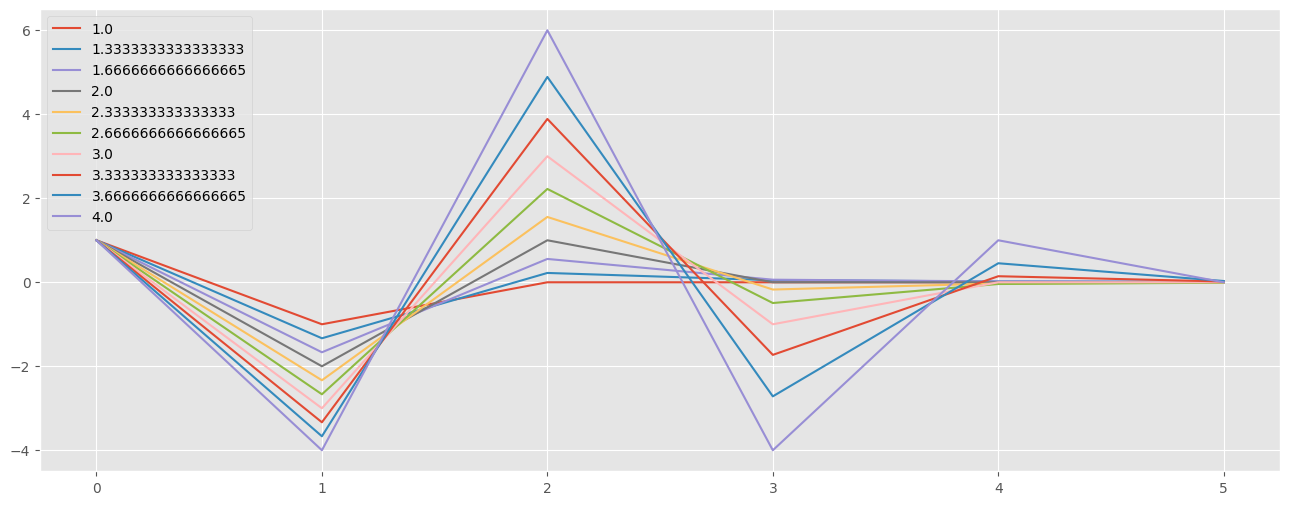

In [7]:
def getWeights(d, size):
    # thres>0 drops insignificant weights
    w = [1.]
    for k in range(1, size):
        w_ = -w[-1] / k * (d - k + 1)
        w.append(w_)
    w = np.array(w[::-1]).reshape(-1, 1)
    return w

#-------------------------------------------------
def plotWeights(dRange, nPlots, size):
    w = pd.DataFrame()
    for d in np.linspace(dRange[0], dRange[1], nPlots):
        w_ = getWeights(d, size=size)
        w_ = pd.DataFrame(w_, index=range(w_.shape[0])[::-1], columns=[d])
        w = w.join(w_, how='outer')
    ax = w.plot()
    ax.legend(loc='upper left')
    plt.show()
    return

#-------------------------------------------------
if __name__ == '__main__':
    plotWeights(dRange=[0, 1], nPlots=3, size=6)
    plotWeights(dRange=[1, 2], nPlots=3, size=6)
    plotWeights(dRange=[1, 4], nPlots=10, size=6)
